In [189]:
#importng basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
#importing Linear Regression and train test
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [191]:
df=pd.read_csv(r"E:\Praxis\TERM1\Foml\100 Days\Data\placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in LPA)')

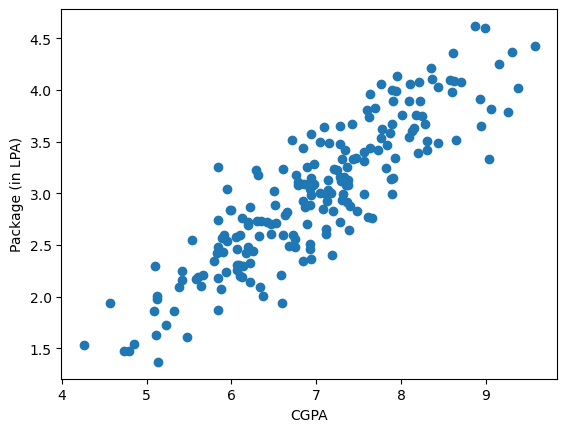

In [192]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')

In [193]:
X=df.drop('package',axis=1)
y=df['package']

In [194]:
#features
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [195]:
#labels
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [196]:
#splitting the dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

# Using LR directly from Sk learn

In [197]:
#instantiate the model
Lr=LinearRegression()

In [198]:
Lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [199]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [200]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [201]:
y_pred_train=Lr.predict(X_train)
y_pred_train

array([3.08766517, 4.0863992 , 2.12798777, 1.94944314, 3.43917491,
       2.87564342, 2.94817717, 2.83100726, 3.51728819, 3.50612915,
       3.96364977, 3.53960627, 2.79195062, 2.59666743, 2.74731446,
       2.68593975, 1.95502266, 2.5018156 , 2.97049525, 3.03186997,
       2.4181228 , 2.47949752, 2.35674808, 2.42370232, 4.29842095,
       2.21726009, 3.50054963, 2.52413367, 3.43359539, 1.80995515,
       2.55761079, 3.90227505, 2.49065656, 3.10998325, 1.96060218,
       3.22715316, 3.70699186, 3.72373042, 3.08208565, 3.20483508,
       2.26189625, 2.4460204 , 3.57308338, 3.08766517, 2.64130359,
       2.94817717, 2.12798777, 2.71383735, 3.39453875, 3.23273268,
       3.16577844, 2.42370232, 3.22157364, 2.97049525, 4.11987632,
       3.2104146 , 3.05418805, 2.10566969, 3.322005  , 3.6902533 ,
       2.3623276 , 2.88680246, 3.11556277, 3.16577844, 2.89238198,
       2.51855416, 2.9258591 , 3.67909426, 2.92027958, 3.21599412,
       2.57434935, 2.79195062, 2.0219769 , 3.12672181, 2.92585

Text(0, 0.5, 'Package (in LPA)')

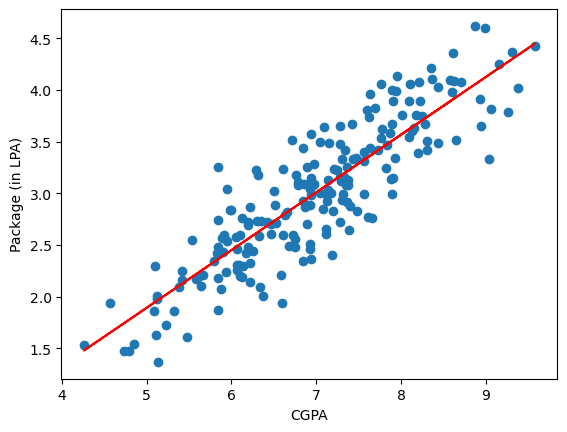

In [202]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,y_pred_train,c='r')
plt.xlabel('CGPA')
plt.ylabel('Package (in LPA)')

In [203]:
#slope
m=Lr.coef_
m

array([0.55795197])

In [204]:
#intercept
c=Lr.intercept_
c

np.float64(-0.8961119222429144)

In [205]:
#y=mx+c
y0=m*8.58+c
y0

array([3.89111601])

In [206]:
y1=m*7.15+c
y1

array([3.09324469])

In [207]:
y_pred_test=Lr.predict(X_test)
y_pred_test[0]

np.float64(3.891116009744203)

# Creating LR class from Scratch

In [208]:
class Lr:
    def __init__(self):
        self.m =None
        self.c =None

    def fit(self,X_train,y_train):
        num=0
        den=0

        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] -y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())**2)

        self.m = num/den
        self.c = y_train.mean() - (self.m *X_train.mean())
        print(self.m)
        print(self.c)

    def predict(self,X_test):
        print(X_test)
        return self.m * X_test + self.c

In [209]:
self_Lr=Lr()

In [210]:
X_train

,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
...,...
43,7.66
22,6.14
72,7.78
15,7.25


In [211]:
X=X.values

In [212]:
y=y.values

In [213]:
#splitting the dataset
X_train_self,X_test_self,y_train_self,y_test_self=train_test_split(X,y,test_size=0.2,random_state=2)

In [214]:
self_Lr.fit(X_train_self,y_train_self)

[0.55795197]
[-0.89611192]


In [215]:
X_test_self[0]

array([8.58])

In [218]:
self_Lr.predict(X_test_self[0])

[8.58]


array([3.89111601])